In [1]:
%pip install torch torchvision transformers matplotlib

  Using cached torch-2.13.0-cp311-cp311-win_amd64.whl.metadata (39 kB)
  Using cached torchvision-0.28.0-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
  Using cached transformers-5.15.0-py3-none-any.whl.metadata (32 kB)
  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached filelock-3.32.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached huggingface_hub-1.27.0-py3-none-any.whl.metadata (16 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.7.1


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# matplotlib 시각화를 주피터 노트북 내에서 직접 볼 수 있도록 설정하는 매직 명령어
%matplotlib inline

# 3-1. CNN과 전이학습 — 이미지 분류기 만들기

> **📌 이 노트북의 위치**
>
> 1-2 챕터에서 **MLP**로 손글씨 숫자를 분류했다.
> 그때 우리는 28x28 이미지를 **한 줄(784)로 펴서(Flatten)** 넣었고,
> 그 과정에서 **"이 픽셀과 저 픽셀이 원래 붙어 있었다"는 정보를 통째로 버렸다.**
>
> 이번 챕터에서는 그 정보를 살리는 모델, **CNN(합성곱 신경망)** 을 배운다.
>
> 그리고 좋은 소식 하나. **학습 4단계(순전파 -> 손실 -> 역전파 -> 업데이트)는 그대로다.**
> 구조만 바뀌고 학습 코드는 1-2 챕터와 거의 동일하다.

## 학습 목표

1. CNN이 MLP와 무엇이 다른지, **왜 이미지에 유리한지** 설명할 수 있다
2. `Conv2d`와 `MaxPool2d`의 역할과 **출력 크기 계산**을 이해한다
3. CIFAR-10 이미지 분류기를 **직접 학습시키고 평가**할 수 있다
4. **전이학습**이 무엇이며 왜 실무의 기본값인지 이해한다

---

## 1. 데이터는 어떻게 하나요?

일반적으로 이미지나 텍스트, 오디오나 비디오 데이터를 다룰텐데요, 이러한 데이터는
표준 Python 패키지를 사용하여 불러온 후 NumPy 배열로 변환하면 됩니다.
그리고 그 배열을 `torch.*Tensor` 로 변환하면 됩니다.

| 데이터 종류 | 자주 쓰는 패키지 |
|---|---|
| 이미지 | Pillow, OpenCV |
| 오디오 | SciPy, LibROSA |
| 텍스트 | NLTK, SpaCy (또는 2-1에서 배운 `tokenizers`) |

특별히 영상 분야를 위해서는 **`torchvision`** 이라는 패키지가 있습니다.
여기에는 ImageNet, CIFAR10, MNIST 등 자주 쓰는 데이터셋을 불러오는 기능과
이미지 변환기(`transforms`)가 포함되어 있어, 매번 비슷한 코드를 반복해서
작성하는 것을 피할 수 있습니다.

### CIFAR-10 데이터셋

이 튜토리얼에서는 **CIFAR-10** 데이터셋을 사용합니다.

| 항목 | 내용 |
|---|---|
| 클래스 | 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭 (**10종**) |
| 이미지 크기 | **3 x 32 x 32** (채널 3, 가로세로 32픽셀) |
| 전체 | 60,000장 (학습 50,000 / 테스트 10,000) |

<br>

> **💡 "3채널"이 무슨 뜻인가?**
>
> 컬러 이미지는 **빨강(R), 초록(G), 파랑(B)** 세 장의 흑백 이미지를 겹친 것이다.
> 각 장이 32x32 크기이므로, 이미지 하나는 `3 x 32 x 32 = 3,072`개의 숫자로 이루어져 있다.
>
> ```
>    R 채널 (32x32)  ┐
>    G 채널 (32x32)  ├─ 겹치면 컬러 이미지 한 장
>    B 채널 (32x32)  ┘
> ```
>
> ⚠️ PyTorch는 채널을 **맨 앞**에 둔다. (`C x H x W`)
> 반면 matplotlib 등은 채널을 **맨 뒤**에 둔다. (`H x W x C`)
> 그래서 시각화할 때 `np.transpose(npimg, (1, 2, 0))` 같은 변환이 필요하다.

> **💡 32x32는 아주 작은 이미지다**
>
> 요즘 스마트폰 사진이 4000x3000 정도인 것과 비교하면 엄지손톱보다 작다.
> 사람이 봐도 흐릿해서 개와 고양이를 헷갈릴 정도다.
> 그래서 이 데이터셋에서 정확도 60%만 나와도 나쁘지 않은 수준이다.

![](https://tutorials.pytorch.kr/_images/cifar10.png)

---

## 2. 이미지 분류기 학습하기

다음의 단계로 진행해보겠습니다:

1. `torchvision` 을 사용하여 CIFAR10의 학습용 / 시험용 데이터셋을 불러오고, 정규화(normalizing)합니다.
2. 합성곱 신경망(Convolution Neural Network)을 정의합니다.
3. 손실 함수를 정의합니다.
4. 학습용 데이터를 사용하여 신경망을 학습합니다.
5. 시험용 데이터를 사용하여 신경망을 검사합니다.

> 📌 **1-2 챕터를 떠올려 보자.** 순서가 똑같다.
> 데이터 준비 -> 모델 정의 -> 손실/옵티마이저 -> 학습 루프 -> 평가.
> **딥러닝 코드의 뼈대는 어떤 모델이든 동일하다.**


### 2.1 CIFAR10를 불러오고 정규화하기

``torchvision`` 을 사용하면 매우 쉽게 CIFAR10 데이터를 불러올 수 있습니다.

In [3]:
# 딥러닝 프레임워크인 PyTorch와 이미지 처리를 위한 torchvision 라이브러리를 임포트합니다.
import torch
import torchvision
# torchvision 내의 transforms는 이미지 전처리(augmentation, normalization 등) 기능을 제공합니다.
import torchvision.transforms as transforms

torchvision 데이터셋의 출력(output)은 [0, 1] 범위를 갖는 PILImage 이미지입니다.
이를 **[-1, 1]의 범위로 정규화**된 Tensor로 변환하겠습니다.

> **💡 왜 정규화를 하는가?**
>
> 픽셀 값은 원래 0~255 범위의 정수다. 이 값을 그대로 넣으면 숫자가 너무 커서
> 기울기도 커지고, 학습이 불안정해진다. (1-1 챕터의 `StandardScaler`와 같은 이유다)
>
> ```
>    0 ~ 255   ──ToTensor()──>   0.0 ~ 1.0   ──Normalize()──>   -1.0 ~ 1.0
>    원본 픽셀                    0~1로 축소                     0 중심으로 이동
> ```
>
> `Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))`는 각 채널에서 **0.5를 빼고 0.5로 나눈다.**
> `(0 - 0.5) / 0.5 = -1`, `(1 - 0.5) / 0.5 = 1` 이므로 범위가 `[-1, 1]`이 된다.
>
> **0을 중심으로 만드는 것**이 핵심이다. 값이 한쪽으로 치우쳐 있으면
> 기울기도 한 방향으로만 쏠려서 학습이 지그재그로 진행된다.

> **📌 실무에서는 데이터셋의 실제 통계를 쓴다**
>
> 여기서는 편의상 평균과 표준편차를 모두 0.5로 뒀지만,
> 실무에서는 **해당 데이터셋에서 실제로 계산한 값**을 사용한다.
> 예를 들어 ImageNet 사전학습 모델을 쓸 때는 아래 값이 표준이다.
>
> ```python
> transforms.Normalize(mean=[0.485, 0.456, 0.406],
>                      std=[0.229, 0.224, 0.225])
> ```
>
> ⚠️ **사전학습 모델을 쓸 때는 그 모델이 학습된 것과 같은 정규화 값을 써야 한다.**
> 다른 값을 쓰면 모델이 전혀 다른 밝기의 이미지를 보는 셈이 되어 성능이 크게 떨어진다.
> (2-1 챕터의 "토크나이저와 모델의 이름을 맞춰야 한다"와 같은 원리다)

> **[참고]**
> Windows 환경에서 `BrokenPipeError`가 발생한다면,
> `torch.utils.data.DataLoader()`의 `num_workers`를 **0**으로 설정해보세요.


In [4]:
# 1. 이미지 전처리 규칙을 정의합니다. transforms.Compose를 사용해 여러 단계를 순차적으로 실행합니다.
transform = transforms.Compose(
    [# 2. PIL Image나 NumPy 배열 형태의 이미지를 PyTorch가 다룰 수 있는 Tensor로 변환합니다.
     #    이 과정에서 픽셀 값의 범위를 [0, 255]에서 [0.0, 1.0]으로 자동으로 조정(스케일링)합니다.
     transforms.ToTensor(),

     # 3. 텐서의 값을 정규화(Normalize)합니다.
     #    (R, G, B) 각 채널에 대해 평균(0.5)을 빼고 표준편차(0.5)로 나누어, 픽셀 값의 범위를 [-1.0, 1.0]으로 조정합니다.
     #    이는 모델의 학습을 더 안정적으로 만들어줍니다.
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# CIFAR-10 학습용 데이터셋을 다운로드하고, 위에서 정의한 전처리(transform)를 적용합니다.
# root: 데이터가 저장될 경로
# train=True: 학습용 데이터셋임을 명시
# download=True: 해당 경로에 데이터가 없으면 자동으로 다운로드
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

# DataLoader는 데이터셋을 모델에 효율적으로 공급하는 역할을 합니다.
# trainset: 사용할 데이터셋
# batch_size=4: 한 번에 4개의 이미지를 묶어서 모델에 전달
# shuffle=True: 각 에폭(epoch)마다 데이터의 순서를 무작위로 섞어 모델이 데이터 순서에 과적합되는 것을 방지
# num_workers=2: 데이터 로딩에 사용할 CPU 프로세서의 수
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

# CIFAR-10 테스트용 데이터셋을 동일한 방식으로 준비합니다.
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
# 테스트 시에는 데이터 순서를 섞을 필요가 없으므로 shuffle=False로 설정합니다.
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

# 분류할 10개의 클래스 이름을 튜플로 정의합니다.
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [21:40<00:00, 131kB/s]  


재미삼아 학습용 이미지 몇 개를 보겠습니다.

> **💡 코드에서 눈여겨볼 두 줄**
>
> ```python
> img = img / 2 + 0.5                       # 정규화 되돌리기 (unnormalize)
> np.transpose(npimg, (1, 2, 0))            # (C,H,W) -> (H,W,C)
> ```
>
> 정규화된 `[-1, 1]` 값을 그대로 그리면 색이 이상하게 나온다.
> 그래서 `[0, 1]`로 되돌린 뒤, **채널 순서까지 바꿔서** 그려야 한다.
>
> ⚠️ 이미지가 흐릿하게 보여도 정상이다. 32x32는 원래 그 정도 해상도다.


ship  bird  frog  car  


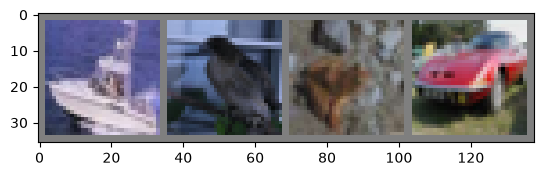

In [5]:
# 2. 데이터 시각화
import matplotlib.pyplot as plt
import numpy as np

# 이미지 시각화를 위한 함수 정의
def imshow(img):
    # 정규화된 이미지 픽셀 값(-1.0 ~ 1.0)을 다시 원래 범위(0.0 ~ 1.0)로 되돌립니다. (unnormalize)
    img = img / 2 + 0.5
    # PyTorch 텐서를 시각화를 위해 NumPy 배열로 변환합니다.
    npimg = img.numpy()
    # PyTorch의 텐서 차원 순서(채널, 높이, 너비)를 Matplotlib이 인식하는 순서(높이, 너비, 채널)로 변경합니다.
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# 학습용 데이터 로더에서 이터레이터(iterator)를 생성합니다.
dataiter = iter(trainloader)
# 이터레이터에서 이미지와 레이블 한 배치를 가져옵니다.
images, labels = next(dataiter)

# torchvision.utils.make_grid 함수는 여러 이미지를 하나의 그리드 이미지로 만들어줍니다.
imshow(torchvision.utils.make_grid(images))

# 가져온 배치에 포함된 이미지들의 실제 정답(label)을 출력합니다.
batch_size = 4
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

### 2.2 합성곱 신경망(Convolutional Neural Network) 정의하기

여기가 이번 챕터의 핵심이다. 코드를 보기 전에 **CNN이 무엇인지** 부터 이해하자.

#### 왜 MLP로는 부족한가?

1-2 챕터에서 우리는 이미지를 **한 줄로 펴서(Flatten)** MLP에 넣었다.
그런데 여기에 두 가지 큰 문제가 있다.

**문제 1. 위치 정보가 사라진다**

```
   원본 (붙어 있음)        Flatten 후 (멀어짐)
   ┌───┬───┬───┐
   │ A │ B │ C │          [A, B, C, D, E, F, G, H, I]
   ├───┼───┼───┤           ↑        ↑
   │ D │ E │ F │            A와 D는 원래 위아래로 붙어 있었는데
   ├───┼───┼───┤            펴고 나니 3칸이나 떨어져 버렸다
   │ G │ H │ I │
   └───┴───┴───┘
```

이미지에서 **바로 옆 픽셀**은 거의 같은 색이고, 함께 모양을 이룬다.
이 관계가 사라지면 모델은 "선"이나 "모서리" 같은 기본 형태조차 배우기 어렵다.

**문제 2. 파라미터가 폭발한다**

CIFAR-10 이미지(3x32x32 = 3,072개)를 은닉층 1,000개짜리 MLP에 넣는다면?

```
   3,072 x 1,000 = 307만 개    ← 첫 층 하나에만!
```

가로세로가 두 배(64x64)만 되어도 파라미터는 네 배가 된다. 감당이 안 된다.

**문제 3. 위치가 조금만 바뀌어도 못 알아본다**

고양이가 사진 왼쪽에 있을 때 학습했는데, 오른쪽에 있는 고양이는 완전히 다른 입력이 된다.
MLP는 이 둘을 **별개로 다시 배워야 한다.**

---

#### CNN의 아이디어 — "돋보기로 훑는다"

CNN은 이미지 전체를 한 번에 보지 않는다.
**작은 돋보기(필터)를 들고 이미지 위를 조금씩 옮겨가며 훑는다.**

```
   이미지 (32x32)                필터 (5x5)
   ┌─────────────────┐          ┌───┐
   │ ▩▩▩▩▩ · · · · · │  ←────   │▩▩▩│   이 돋보기로
   │ ▩▩▩▩▩ · · · · · │          │▩▩▩│   왼쪽 위부터
   │ ▩▩▩▩▩ · · · · · │          └───┘   오른쪽 아래까지
   │ · · · · · · · · │                  한 칸씩 옮기며 훑는다
   └─────────────────┘
```

이 방식이 세 가지 문제를 한 번에 해결한다.

| 문제 | CNN의 해결 |
|---|---|
| 위치 정보 소실 | 필터가 **인접한 픽셀을 묶어서** 보므로 관계가 유지된다 |
| 파라미터 폭발 | 필터 하나는 `5x5x3 = 75`개뿐. **같은 필터를 전체에 재사용**한다 |
| 위치 변화에 취약 | 같은 필터가 이미지 전체를 훑으므로 **어디에 있든 찾아낸다** |

<br>

> **💡 핵심 개념: 파라미터 공유(Parameter Sharing)**
>
> MLP는 픽셀마다 다른 가중치를 갖는다. CNN은 **하나의 필터를 이미지 전체에 재사용**한다.
> "세로선을 찾는 필터"를 한 번 배우면, 이미지 어디에 있는 세로선이든 찾을 수 있다.
> 이것이 CNN이 적은 파라미터로도 잘 작동하는 이유다.

---

#### 층이 깊어지면 무엇이 달라지나

CNN을 여러 층 쌓으면, 층마다 **점점 복잡한 특징**을 배운다.

```
   1층    →  선, 모서리, 색 변화       (가장 단순한 조각)
   2층    →  곡선, 모서리 조합, 무늬
   3층    →  눈, 코, 바퀴, 날개        (부분 형태)
   깊은 층 →  고양이 얼굴, 자동차       (전체 형태)
```

> **💡 1-2 챕터의 "종이 접기"를 기억하는가?**
>
> MLP의 은닉층이 공간을 접어서 직선으로 나눌 수 있게 만들었듯,
> CNN의 층도 **단순한 특징을 조합해 복잡한 특징을 만든다.**
> 원리는 같고, "무엇을 조합하는가"가 다를 뿐이다.
>
> 그리고 **가장 중요한 것**: 이 특징들을 사람이 설계하지 않았다.
> 모델이 학습을 통해 **스스로 찾아낸 것**이다.
> (1-2 챕터에서 말한 "딥러닝은 특징을 스스로 학습한다"가 여기서 실현된다)

---

#### 핵심 부품 3가지

**① `nn.Conv2d` — 합성곱 층 (특징을 뽑는다)**

```python
nn.Conv2d(in_channels, out_channels, kernel_size)
nn.Conv2d(3, 6, 5)   # 3채널 입력 -> 6채널 출력, 5x5 필터
```

| 인자 | 뜻 | 비유 |
|---|---|---|
| `in_channels` | 입력 채널 수 | 들어오는 이미지가 몇 장인가 (RGB면 3) |
| `out_channels` | **필터 개수** | 돋보기를 몇 개 쓸 것인가 |
| `kernel_size` | 필터 크기 | 돋보기가 얼마나 넓게 보는가 |

⚠️ **가장 헷갈리는 규칙**: `conv1`의 `out_channels`와 `conv2`의 `in_channels`는 **반드시 같아야 한다.**
앞 층이 6장을 내보내면 뒤 층은 6장을 받아야 하기 때문이다.

**② `nn.MaxPool2d` — 풀링 층 (크기를 줄인다)**

```python
nn.MaxPool2d(2, 2)   # 2x2 영역에서 가장 큰 값 하나만 남긴다
```

```
   ┌───┬───┐
   │ 1 │ 5 │        2x2 중 최댓값
   ├───┼───┤   ─────────────────>   8
   │ 3 │ 8 │
   └───┴───┘
```

- **크기를 절반으로** 줄여 계산량을 감소시킨다
- **가장 두드러진 특징만** 남긴다 ("이 영역에 세로선이 있긴 있다")
- 위치가 조금 흔들려도 같은 결과가 나온다 (**약간의 위치 변화에 강해진다**)

**③ `torch.flatten` — 평탄화 (분류기로 넘긴다)**

특징을 다 뽑았으면, 마지막에는 **1-2 챕터에서 배운 MLP**로 넘겨서 분류한다.

```
   [Conv + Pool 반복]  ->  [Flatten]  ->  [Linear 층들]  ->  10개 클래스
        특징 추출부                          분류부
      "무엇이 보이는가"                   "그래서 무엇인가"
```

> **💡 CNN = 특징 추출부(Conv) + 분류부(MLP)**
>
> 이 구조를 기억해 두자. **잠시 뒤 배울 전이학습의 핵심**이 여기서 나온다.

---

#### ⭐ 출력 크기 계산 — 코드의 `16 * 5 * 5`는 어디서 왔나

아래 코드에 `nn.Linear(16 * 5 * 5, 120)`이 나온다. 이 숫자를 직접 따라가 보자.

**공식** (패딩 없음, stride 1 기준)

```
   출력 크기 = 입력 크기 - 커널 크기 + 1
```

**단계별 추적**

| 단계 | 연산 | 크기 변화 | 계산 |
|---|---|---|---|
| 입력 | — | **3 x 32 x 32** | 원본 |
| conv1 | `Conv2d(3, 6, 5)` | 6 x **28** x 28 | 32 - 5 + 1 = 28 |
| pool | `MaxPool2d(2,2)` | 6 x **14** x 14 | 28 ÷ 2 = 14 |
| conv2 | `Conv2d(6, 16, 5)` | 16 x **10** x 10 | 14 - 5 + 1 = 10 |
| pool | `MaxPool2d(2,2)` | 16 x **5** x 5 | 10 ÷ 2 = 5 |
| flatten | — | **400** | 16 x 5 x 5 = 400 |

**그래서 `nn.Linear(400, 120)`이 되는 것이다.**

> ⚠️ **딥러닝 초보자가 가장 많이 만나는 에러가 이것이다.**
>
> ```
> RuntimeError: mat1 and mat2 shapes cannot be multiplied (4x400 and 500x120)
> ```
>
> 이 에러는 **Flatten 후의 크기와 `nn.Linear`의 입력 크기가 안 맞을 때** 난다.
> 위 표처럼 한 단계씩 직접 계산해 보면 반드시 원인을 찾을 수 있다.
>
> 💡 **더 쉬운 방법**: `forward` 안에 `print(x.shape)`를 넣고 한 번 실행해 보면
> 실제 크기가 바로 찍힌다. 계산이 헷갈리면 이 방법을 쓰자.

> **📌 `padding`을 쓰면 크기가 안 줄어든다**
>
> ```python
> nn.Conv2d(3, 6, 5, padding=2)   # 32 -> 32 (크기 유지)
> ```
> 가장자리에 0을 둘러서 크기를 유지하는 기법이다.
> 요즘 모델들은 대부분 `padding`을 써서 Conv 층에서는 크기를 유지하고,
> **Pooling에서만 크기를 줄인다.** 계산이 훨씬 단순해지기 때문이다.

---

이제 실제 코드를 보자.
아래 모델은 `Conv -> Pool -> Conv -> Pool -> Linear x 3` 구조다.


In [6]:
# 3. CNN 모델 정의

import torch.nn as nn
import torch.nn.functional as F

# nn.Module을 상속받아 CNN 모델 클래스를 정의합니다.
class Net(nn.Module):
    # 모델의 구조와 필요한 레이어를 정의하는 __init__ 메서드
    def __init__(self):
        super(Net, self).__init__()
        # 첫 번째 합성곱 레이어 (nn.Conv2d)
        # in_channels=3: 입력 이미지의 채널 수 (RGB)
        # out_channels=6: 사용할 필터의 개수, 즉 출력 특징 맵(feature map)의 개수
        # kernel_size=5: 5x5 크기의 필터(커널)
        self.conv1 = nn.Conv2d(3, 6, 5)

        # 최대 풀링 레이어 (nn.MaxPool2d)
        # kernel_size=2, stride=2: 2x2 크기의 윈도우로 특징 맵을 훑으며, 2칸씩 이동합니다.
        # 이 과정을 통해 특징 맵의 가로, 세로 크기가 절반으로 줄어듭니다.
        self.pool = nn.MaxPool2d(2, 2)
        # 두 번째 합성곱 레이어
        # in_channels=6: 이전 conv1 레이어의 출력 채널 수와 동일해야 합니다.
        # out_channels=16: 16개의 필터를 사용해 16개의 특징 맵을 생성합니다.
        self.conv2 = nn.Conv2d(6, 16, 5)

        # 완전 연결 레이어 (nn.Linear, MLP) - 분류기 역할
        # in_features=16 * 5 * 5: 입력으로 들어오는 1차원 벡터의 크기.
        # (32x32 -> conv1(28x28) -> pool1(14x14) -> conv2(10x10) -> pool2(5x5))
        # 최종 특징 맵은 16개 채널의 5x5 크기이므로, 총 16*5*5=400개의 노드가 됩니다.
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        # 최종 출력은 10개 클래스에 대한 점수(score)여야 하므로 out_features=10
        self.fc3 = nn.Linear(84, 10)

    # 데이터가 모델을 통과하는 순서, 즉 순전파(forward pass) 과정을 정의하는 메서드
    def forward(self, x):
        # Conv1 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        # Conv2 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        # 2차원 특징 맵을 1차원 벡터로 평탄화(flatten)합니다.
        # start_dim=1: 배치 차원(0)은 유지하고 나머지 차원(1, 2, 3)을 하나로 합칩니다.
        x = torch.flatten(x, 1)
        # 완전 연결 레이어 통과
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 정의한 Net 클래스를 이용해 모델 객체(net)를 생성합니다.
net = Net()

### 2.3 손실 함수와 Optimizer 정의하기

분류 문제이므로 **교차 엔트로피 손실(Cross-Entropy Loss)** 과,
**momentum을 갖는 SGD** 옵티마이저를 사용합니다.

> **💡 1-2 챕터에서 배운 그대로다**
>
> | | 1-2 (MLP) | 3-1 (CNN) |
> |---|---|---|
> | 손실 함수 | `CrossEntropyLoss` | **동일** |
> | 출력층 | Softmax 없음 (logits) | **동일** |
> | 옵티마이저 | Adam | SGD + momentum |
>
> **모델 구조만 바뀌었을 뿐, 학습 방식은 완전히 같다.**

> **⚠️ 여기서도 Softmax를 넣지 않는다**
>
> 위 모델의 마지막 층이 `nn.Linear(84, 10)`으로 그냥 끝나는 것을 확인했는가?
> **`nn.CrossEntropyLoss` 안에 Softmax가 이미 들어 있기 때문**이다.
> 또 넣으면 이중 적용되어 학습이 망가진다. (1-2 챕터에서 강조한 내용)

> **💡 momentum이 무엇인가?**
>
> 1-2 챕터에서 배운 Adam의 구성 요소 중 하나다.
> **이전에 움직이던 방향을 기억해서 관성처럼 밀어주는** 것이다.
>
> - 좌우로 요동치는 움직임이 상쇄되어 **부드럽게 내려간다**
> - 작은 웅덩이(지역 최저점)에 빠져도 **관성으로 빠져나올 수 있다**
>
> `momentum=0.9`는 "이전 방향의 90%를 유지한다"는 뜻으로, 사실상 표준값이다.


In [7]:
# 4. 손실 함수와 옵티마이저 정의

import torch.optim as optim

# 손실 함수(Loss Function)로 다중 클래스 분류에 널리 사용되는 교차 엔트로피 손실을 사용합니다.
criterion = nn.CrossEntropyLoss()
# 옵티마이저(Optimizer)로 경사 하강법(SGD)을 사용합니다.
# net.parameters(): 모델의 모든 학습 가능한 파라미터(가중치, 편향)를 최적화 대상으로 지정
# lr=0.001: 학습률(learning rate)
# momentum=0.9: 이전 업데이트의 방향을 일정 비율 유지하여, 더 빠르고 안정적인 수렴을 돕는 기법
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

### 2.4 신경망 학습하기

데이터를 반복해서 신경망에 입력으로 제공하고, 최적화(Optimize)하면 됩니다.

> **💡 학습 루프 5줄 — 1-2 챕터와 완전히 동일하다**
>
> ```python
> optimizer.zero_grad()              #    기울기 초기화 (칠판 지우기)
> outputs = net(inputs)              # ① 순전파
> loss = criterion(outputs, labels)  # ② 손실 계산
> loss.backward()                    # ③ 역전파
> optimizer.step()                   # ④ 가중치 업데이트
> ```
>
> **CNN이든 MLP든 Transformer든 이 다섯 줄은 그대로다.**
> 오늘 바뀐 것은 `net`의 내부 구조뿐이다.

> **⚠️ 시간이 꽤 걸린다 (CPU 기준 10~20분)**
>
> 이 셀은 `batch_size=4`로 50,000장을 2바퀴 도므로 **총 25,000회 업데이트**를 한다.
> 진행 상황은 2,000배치마다 출력되니, 숫자가 찍히면 정상 작동 중이다.
>
> 💡 **너무 오래 걸린다면** `batch_size`를 64 이상으로 올려보자.
> 한 번에 처리하는 양이 늘어 훨씬 빨라진다. (`DataLoader` 셀을 수정 후 재실행)

> **📊 무엇을 관찰해야 하는가**
>
> 출력되는 **loss 값이 계속 줄어드는지** 확인하자.
> ```
> [1,  2000] loss: 2.213     ← 처음엔 ln(10) ≈ 2.303 근처에서 출발
> [1,  4000] loss: 1.885     ← 줄어들고 있다 ✅
> [2,  2000] loss: 1.412
> ```
>
> **왜 2.3에서 시작하나?** 학습 전 모델은 10개 클래스에 균등하게 0.1씩 준다.
> `-ln(0.1) = 2.303`. 이 숫자에서 크게 벗어나 시작한다면 데이터나 레이블 설정을 의심해야 한다.
>
> ⚠️ loss가 **줄지 않거나 `nan`이 되면** 학습률(`lr`) 문제일 가능성이 높다.


In [8]:
# 5. 신경망 학습 (Training Loop)
# 전체 데이터셋을 2번 반복하여 학습합니다 (epoch=2).
for epoch in range(2):

    # 손실 값을 누적하여 일정 주기마다 평균을 계산하기 위한 변수
    running_loss = 0.0
    # trainloader에서 미니배치 단위로 데이터를 가져옵니다. i는 배치의 인덱스입니다.
    for i, data in enumerate(trainloader, 0):
        # data는 [입력 이미지 텐서, 정답 레이블 텐서]로 구성된 리스트입니다.
        inputs, labels = data

        # 1. 기울기 초기화: PyTorch는 기울기를 누적하므로, 새로운 배치를 학습하기 전에 항상 0으로 초기화해야 합니다.
        optimizer.zero_grad()

        # 2. 순전파(Forward Pass): 모델에 입력을 넣어 예측값을 계산합니다.
        outputs = net(inputs)
        # 3. 손실 계산: 예측값과 실제 정답 레이블 간의 오차(손실)를 계산합니다.
        loss = criterion(outputs, labels)
        # 4. 역전파(Backward Pass): 손실을 바탕으로 각 파라미터에 대한 기울기를 계산합니다.
        loss.backward()
        # 5. 가중치 업데이트: 계산된 기울기를 이용해 옵티마이저가 모델의 가중치를 업데이트합니다.
        optimizer.step()

        # 학습 과정 통계 출력
        # loss.item()은 텐서에서 스칼라 값만 추출합니다.
        running_loss += loss.item()
        # 2000개의 미니배치를 처리할 때마다 평균 손실을 출력합니다.
        if i % 2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            # running_loss를 다시 0으로 초기화합니다.
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.211
[1,  4000] loss: 1.902
[1,  6000] loss: 1.731
[1,  8000] loss: 1.612
[1, 10000] loss: 1.545
[1, 12000] loss: 1.476
[2,  2000] loss: 1.410
[2,  4000] loss: 1.379
[2,  6000] loss: 1.362
[2,  8000] loss: 1.334
[2, 10000] loss: 1.288
[2, 12000] loss: 1.276
Finished Training


### 2.5 시험용 데이터로 신경망 검사하기

학습용 데이터셋을 2회 반복하여 신경망을 학습시켰는데요, 신경망이 전혀 배운 게
없을지도 모르니 확인해 보겠습니다.

신경망이 예측한 정답과 진짜 정답(Ground-truth)을 비교하는 방식으로 확인할 텐데요,
예측이 맞다면 샘플을 '맞은 예측값(Correct predictions)'에 넣겠습니다.

> **⭐ 왜 학습에 쓰지 않은 데이터로 평가하는가?**
>
> 1-1 챕터의 **train / test 분할**과 같은 이유다.
> 학습에 쓴 데이터로 평가하면 "기출문제 답을 외운 수험생"에게 기출을 다시 내는 것과 같다.
> 우리가 알고 싶은 것은 **처음 보는 이미지도 맞히는가**이다.
>
> CIFAR-10은 처음부터 학습용 50,000장과 테스트용 10,000장이 분리되어 제공된다.

첫 번째로 시험용 데이터를 좀 보겠습니다.


GroundTruth:  cat   ship  ship  plane


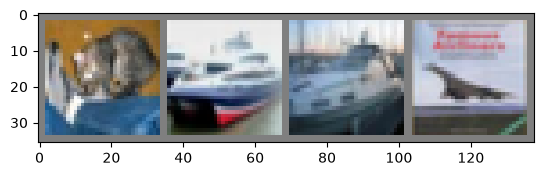

In [9]:
# 6. 모델 평가

# 테스트 데이터 로더에서 이터레이터를 생성합니다.
dataiter = iter(testloader)
# 테스트용 이미지와 레이블 한 배치를 가져옵니다.
images, labels = next(dataiter)

# 가져온 테스트 이미지들을 시각화합니다.
imshow(torchvision.utils.make_grid(images))
# 해당 이미지들의 실제 정답(GroundTruth)을 출력합니다.
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

좋습니다, 이제 신경망이 어떻게 예측했는지를 보죠.

> **📌 원래는 `net.eval()`과 `torch.no_grad()`를 함께 쓴다**
>
> 지금 모델에는 Dropout이나 BatchNorm이 없어서 결과가 달라지지 않는다.
> 하지만 그런 층이 하나라도 들어가는 순간, `net.eval()`을 빠뜨리면
> **"실행할 때마다 정확도가 달라져요"** 라는 버그가 생긴다.
>
> ```python
> net.eval()                 # 평가 모드 (Dropout OFF)
> with torch.no_grad():      # 기울기 계산 생략 -> 메모리 절약
>     outputs = net(images)
> ```
>
> 습관으로 붙이는 것이 좋다. (아래 전체 평가 셀에서는 `no_grad()`를 쓰고 있다)


In [10]:
# 학습된 모델에 테스트 이미지를 입력하여 예측을 수행합니다.
outputs = net(images)

출력은 10개 분류 각각에 대한 값으로 나타납니다. 어떤 분류에 대해서 더 높은 값이
나타난다는 것은, 신경망이 그 이미지가 더 해당 분류에 가깝다고 생각한다는 것입니다.
따라서, 가장 높은 값을 갖는 인덱스(index)를 뽑아보겠습니다.

> **💡 이 10개의 값을 `logits`(로짓)이라고 부른다**
>
> 확률이 아니다. 범위 제한 없이 `-3.2`, `8.7` 같은 값이 그냥 나온다.
> Softmax를 통과시키면 확률이 되지만, **여기서는 그럴 필요가 없다.**
>
> Softmax는 **순서를 바꾸지 않기** 때문이다.
> 가장 큰 logit이 곧 가장 확률이 높은 클래스이므로, `argmax`만으로 답을 뽑을 수 있다.
>
> ```python
> _, predicted = torch.max(outputs, 1)   # 최댓값의 '인덱스'만 필요
> ```
>
> 📌 확률로 보고 싶다면 `torch.softmax(outputs, dim=1)`을 쓰면 된다.
> "이 모델이 얼마나 확신하는가"를 사용자에게 보여줄 때 유용하다.


In [11]:
# torch.max 함수는 (최대값, 최대값의 인덱스)를 반환합니다.
# 우리는 클래스 예측이므로 인덱스만 필요합니다. '_'는 값을 무시하겠다는 의미입니다.
# dim=1: 각 행(이미지)에 대해 가장 큰 값을 가진 열(클래스)의 인덱스를 찾습니다.
_, predicted = torch.max(outputs.data, 1)

# 모델이 예측한 클래스를 출력합니다.
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   car   ship  ship 


결과가 괜찮아 보이네요.

그럼 전체 데이터셋에 대해서는 어떻게 동작하는지 보겠습니다.

> **💡 4장만 보고 판단하면 안 된다**
>
> 방금 본 것은 테스트 데이터 10,000장 중 **단 4장**이다.
> 운 좋게 다 맞았을 수도, 운 나쁘게 다 틀렸을 수도 있다.
> 모델의 성능을 말하려면 **전체 데이터로 측정**해야 한다.


In [12]:
# 전체 테스트 데이터셋에 대한 정확도를 계산합니다.
correct = 0
total = 0
# with torch.no_grad() 블록 내에서는 기울기를 계산하지 않아, 불필요한 연산을 줄이고 메모리를 절약합니다.
# 모델 평가 시에는 반드시 사용해야 합니다.
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # 신경망에 이미지를 통과시켜 출력을 계산합니다.
        outputs = net(images)
        # 가장 높은 점수를 가진 클래스를 예측값으로 선택합니다.
        _, predicted = torch.max(outputs.data, 1)
        # 전체 레이블 수(배치 크기)를 누적합니다.
        total += labels.size(0)
        # 예측이 맞은 개수를 누적합니다. (predicted == labels)는 boolean 텐서를 반환합니다.
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 55 %


(10가지 분류에서 무작위로) 찍었을 때의 정확도인 10% 보다는 나아 보입니다.
신경망이 뭔가 배우긴 한 것 같네요.

> **📊 성능 감 잡기**
>
> | 정확도 | 의미 |
> |---|---|
> | 10% | **찍기 수준** (10개 중 하나니까) |
> | 50~60% | 지금 이 작은 모델 + 2 에포크의 결과 |
> | 80~90% | 잘 설계된 CNN + 충분한 학습 |
> | 95% 이상 | ResNet 등 최신 구조 + **전이학습** |
>
> 우리 결과가 낮아 보여도 실망할 필요 없다.
> **필터 6개짜리 모델로 2바퀴만 돌린 것**이니 당연한 결과다.
> 뒤에서 이 성능을 크게 끌어올리는 방법을 배운다.

> **⚠️ 참고: 코드의 `//`는 정수 나눗셈이다**
>
> `100 * correct // total` 은 소수점을 버린다. 정확히 보려면 `/`를 쓰면 된다.
> ```python
> print(f'Accuracy: {100 * correct / total:.2f} %')
> ```

그럼 어떤 것들을 더 잘 분류하고, 어떤 것들을 더 못했는지 알아보겠습니다.

> **🔍 클래스별 정확도가 왜 중요한가**
>
> 전체 정확도 55%라는 숫자 하나로는 **어디가 문제인지 알 수 없다.**
> 클래스별로 쪼개보면 이런 것들이 보인다.
>
> - **자동차, 배, 트럭**: 대체로 높다 (형태가 뚜렷하고 배경이 단순)
> - **고양이, 개, 사슴**: 대체로 낮다 (서로 비슷하게 생겼고 자세가 다양)
>
> 👉 **모델을 개선하려면 "평균"이 아니라 "어디서 틀리는가"를 봐야 한다.**
> 1-1 챕터에서 정확도 하나만 보면 안 된다고 배운 것과 같은 맥락이다.


In [13]:
# 각 클래스별로 맞춘 개수와 전체 개수를 저장할 딕셔너리를 준비합니다.
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# 기울기를 계산하지 않도록 설정합니다.
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # zip을 이용해 각 이미지의 실제 레이블과 예측 레이블을 하나씩 확인합니다.
        for label, prediction in zip(labels, predictions):
            # 만약 예측이 맞았다면, 해당 클래스의 correct_pred 값을 1 증가시킵니다.
            if label == prediction:
                correct_pred[classes[label]] += 1
            # 해당 클래스의 전체 개수(total_pred)를 1 증가시킵니다.
            total_pred[classes[label]] += 1


# 각 클래스별 정확도를 계산하고 출력합니다.
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 43.5 %
Accuracy for class: car   is 78.4 %
Accuracy for class: bird  is 35.4 %
Accuracy for class: cat   is 38.3 %
Accuracy for class: deer  is 51.0 %
Accuracy for class: dog   is 34.0 %
Accuracy for class: frog  is 68.0 %
Accuracy for class: horse is 64.6 %
Accuracy for class: ship  is 80.3 %
Accuracy for class: truck is 60.7 %


## 3. GPU에서 학습하기

Tensor를 GPU로 옮겼던 것처럼, 신경망도 GPU로 옮길 수 있습니다.
먼저 (CUDA를 사용할 수 있다면) 첫 번째 CUDA 장치를 사용하도록 설정합니다.

> **💡 GPU가 왜 딥러닝에 유리한가?**
>
> | | CPU | GPU |
> |---|---|---|
> | 코어 수 | 적음 (4~16개) | **매우 많음** (수천 개) |
> | 코어 성능 | 강력 | 개별로는 약함 |
> | 비유 | 수학 교수 몇 명 | 초등학생 수천 명 |
>
> 딥러닝은 **단순한 곱셈과 덧셈을 어마어마하게 많이** 하는 작업이다.
> 어려운 문제 몇 개가 아니라, 쉬운 문제 수백만 개를 푸는 셈이다.
> 그래서 **초등학생 수천 명(GPU)** 이 훨씬 유리하다.


In [14]:
%pip uninstall -y torch torchvision

Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
Found existing installation: torchvision 0.28.0
Uninstalling torchvision-0.28.0:
  Successfully uninstalled torchvision-0.28.0
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.


In [15]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132

Looking in indexes: https://download.pytorch.org/whl/cu132
  Using cached https://download-r2.pytorch.org/whl/cu132/torch-2.13.0%2Bcu132-cp311-cp311-win_amd64.whl.metadata (39 kB)
  Using cached https://download-r2.pytorch.org/whl/cu132/torchvision-0.28.0%2Bcu132-cp311-cp311-win_amd64.whl.metadata (5.7 kB)
Using cached https://download-r2.pytorch.org/whl/cu132/torch-2.13.0%2Bcu132-cp311-cp311-win_amd64.whl (1917.9 MB)
Using cached https://download-r2.pytorch.org/whl/cu132/torchvision-0.28.0%2Bcu132-cp311-cp311-win_amd64.whl (8.8 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

## 🔄 [필수] 커널(런타임) 재시작 후 복구하기

> ### ⚠️ 위 셀로 PyTorch를 재설치했다면, **반드시 커널을 재시작해야 합니다.**
>
> 파이썬은 한 번 불러온 라이브러리를 **메모리에 올려둔 채로 계속 사용**합니다.
> 그래서 새 버전을 설치해도, **커널을 재시작하기 전까지는 옛 버전이 그대로 쓰입니다.**
>
> | 환경 | 재시작 방법 |
> |---|---|
> | **Colab** | 상단 메뉴 `런타임` > `세션 다시 시작` |
> | **Jupyter / VS Code** | 상단 `Kernel` > `Restart Kernel` (또는 ⟳ 아이콘) |

### 그런데 재시작하면 문제가 생깁니다

커널을 재시작하면 **메모리가 완전히 비워집니다.**
지금까지 만든 변수가 전부 사라지므로, 아래 셀들이 바로 오류를 냅니다.

```
NameError: name 'torch' is not defined      <- import가 사라짐
NameError: name 'net' is not defined        <- 모델이 사라짐
NameError: name 'data' is not defined       <- 데이터가 사라짐
```

### ✅ 해결: 아래 4개 셀만 실행하면 됩니다

**위로 돌아가서 하나하나 다시 실행할 필요가 없습니다.**
지금까지 필요한 것들을 아래 네 개 셀에 모아두었습니다.
**순서대로 실행한 뒤, 그대로 아래로 계속 진행**하세요.

| 셀 | 복구하는 것 | 원래 위치 |
|:--:|---|---|
| **①** | 라이브러리 import, GPU 확인 | 2.1 |
| **②** | 데이터셋 · DataLoader · `imshow` · `data` | 2.1 ~ 2.2 |
| **③** | `Net` 클래스와 `net` 객체 | 2.2 |
| **④** | 손실 함수 · 옵티마이저 | 2.3 |

> **⚠️ 한 가지만 알아두세요 — 모델은 '학습 전' 상태로 돌아갑니다**
>
> 메모리가 비워졌으므로 앞에서 학습시킨 가중치도 함께 사라집니다.
> 아래 ③번 셀은 **새 모델(무작위 가중치)** 을 만듭니다.
>
> 지금부터 할 일은 **"GPU로 옮기는 방법"과 "속도 차이"를 확인하는 것**이므로
> 학습된 상태가 아니어도 전혀 문제가 없습니다.
> 정확도를 다시 보고 싶다면 아래 **⑤ 재학습 셀**을 실행하면 됩니다.
>
> 💡 실무에서는 이런 일을 막기 위해 학습이 끝나면
> `torch.save(net.state_dict(), 'model.pth')`로 **파일에 저장**해 둡니다.
> (2-2 챕터에서 다룬 체크포인트와 같은 개념입니다)


In [1]:
# ========== ① 라이브러리 import 및 GPU 확인 ==========
# 커널을 재시작하면 import한 것도 전부 사라지므로 다시 불러온다.
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print(f'PyTorch 버전      : {torch.__version__}')
print(f'CUDA 사용 가능 여부: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU 이름          : {torch.cuda.get_device_name(0)}')
    print('\n✅ GPU를 사용할 수 있습니다. 아래로 계속 진행하세요.')
else:
    print('\n⚠️ GPU를 찾지 못했습니다. CPU로도 실습은 진행됩니다.')
    print('   Colab이라면 [런타임 > 런타임 유형 변경 > 하드웨어 가속기: GPU]를 확인하세요.')
    print('   (설정을 바꾸면 런타임이 다시 시작되므로, 이 셀부터 다시 실행하면 됩니다)')

PyTorch 버전      : 2.13.0+cu132
CUDA 사용 가능 여부: True
GPU 이름          : NVIDIA GeForce RTX 3070 Ti

✅ GPU를 사용할 수 있습니다. 아래로 계속 진행하세요.


In [2]:
# ========== ② 데이터셋과 DataLoader 복구 ==========
# 2.1 절에서 했던 것과 완전히 동일한 코드다.
# 데이터는 이미 './data'에 받아두었으므로 재다운로드하지 않는다.

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# 시각화 함수도 다시 정의 (2.1 절과 동일)
def imshow(img):
    img = img / 2 + 0.5                                  # 정규화 되돌리기
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))           # (C,H,W) -> (H,W,C)


# 뒤에 나오는 `inputs, labels = data[0].to(device), ...` 셀에서 사용할 배치 하나
data = next(iter(trainloader))

print(f'학습용 {len(trainset):,}장 / 테스트용 {len(testset):,}장 준비 완료')
print(f'배치 하나의 shape: {tuple(data[0].shape)}  <- (배치, 채널, 높이, 너비)')

학습용 50,000장 / 테스트용 10,000장 준비 완료
배치 하나의 shape: (4, 3, 32, 32)  <- (배치, 채널, 높이, 너비)


In [3]:
# ========== ③ 모델(Net) 복구 ==========
# 2.2 절에서 정의한 것과 완전히 동일한 구조다.
# ⚠️ 가중치는 무작위 초기 상태다 (학습 결과는 재시작과 함께 사라졌다).

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)        # 3채널 입력 -> 6채널, 5x5 필터
        self.pool = nn.MaxPool2d(2, 2)         # 2x2 최대 풀링
        self.conv2 = nn.Conv2d(6, 16, 5)       # 6채널 -> 16채널
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 32->28->14->10->5 이므로 16*5*5
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)           # 10개 클래스

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)                # 배치 차원은 유지하고 평탄화
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

n_params = sum(p.numel() for p in net.parameters())
print(f'모델 생성 완료 | 학습 파라미터 {n_params:,}개')
print('⚠️ 가중치는 무작위 초기 상태입니다. (재학습하려면 아래 ⑤번 셀 실행)')

모델 생성 완료 | 학습 파라미터 62,006개
⚠️ 가중치는 무작위 초기 상태입니다. (재학습하려면 아래 ⑤번 셀 실행)


In [4]:
# ========== ④ 손실 함수와 옵티마이저 복구 ==========
# 2.3 절과 동일하다.
# ⚠️ 옵티마이저는 '생성 시점의 모델 파라미터'를 붙잡으므로,
#    ③에서 모델을 새로 만들었다면 옵티마이저도 반드시 새로 만들어야 한다.

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

print('손실 함수 :', criterion)
print('옵티마이저:', type(optimizer).__name__, '| lr=0.001, momentum=0.9')
print('\n✅ 복구 완료! 이제 아래 셀부터 순서대로 계속 진행하시면 됩니다.')

손실 함수 : CrossEntropyLoss()
옵티마이저: SGD | lr=0.001, momentum=0.9

✅ 복구 완료! 이제 아래 셀부터 순서대로 계속 진행하시면 됩니다.


### ⑤ (선택) GPU에서 다시 학습하고 속도 비교하기

복구는 위 ④번 셀로 끝났습니다. **아래로 그냥 진행하셔도 됩니다.**

다만 *"GPU가 정말 빠른가"* 를 **직접 숫자로 확인**하고 싶다면 아래 셀을 실행해 보세요.
전체를 학습하지 않고 **200배치만 돌려서 시간을 재는** 방식이라 금방 끝납니다.

> **🔬 이렇게 비교해 보세요**
>
> 1. 먼저 지금 상태(GPU)로 아래 셀을 실행하고 시간을 기록한다
> 2. 셀 안의 `device` 를 `torch.device('cpu')` 로 바꿔서 다시 실행한다
> 3. 두 시간을 비교한다
>
> ⚠️ **생각보다 차이가 작을 수 있습니다.** 그 이유는 바로 아래 절에서 설명합니다.
> `BATCH` 값을 4에서 64, 256으로 올려가며 실행하면 차이가 훨씬 뚜렷해집니다.


In [5]:
# ========== ⑤ (선택) GPU 학습 속도 측정 ==========
import time

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
BATCH = 4          # 4 -> 64 -> 256 으로 바꿔가며 실행해 보세요
N_BATCH = 200      # 측정할 배치 수 (전체를 다 돌지 않는다)

speed_loader = torch.utils.data.DataLoader(trainset, batch_size=BATCH,
                                           shuffle=True, num_workers=2)

# 모델과 옵티마이저를 새로 만들어 공정하게 비교한다
speed_net = Net().to(device)
speed_opt = optim.SGD(speed_net.parameters(), lr=0.001, momentum=0.9)

speed_net.train()
start = time.time()
n_images = 0

for i, (inputs, labels) in enumerate(speed_loader):
    if i >= N_BATCH:
        break

    # ⭐ 모델과 데이터는 반드시 같은 장치에 있어야 한다
    inputs, labels = inputs.to(device), labels.to(device)

    speed_opt.zero_grad()                    #    기울기 초기화
    outputs = speed_net(inputs)              # ① 순전파
    loss = criterion(outputs, labels)        # ② 손실 계산
    loss.backward()                          # ③ 역전파
    speed_opt.step()                         # ④ 가중치 업데이트

    n_images += labels.size(0)

# GPU는 명령을 비동기로 처리하므로, 정확히 재려면 끝날 때까지 기다려야 한다
if device.type == 'cuda':
    torch.cuda.synchronize()

elapsed = time.time() - start

print(f'장치      : {device}')
print(f'배치 크기 : {BATCH}')
print(f'처리량    : {N_BATCH}배치 / {n_images:,}장')
print(f'소요 시간 : {elapsed:.2f}초  ({n_images / elapsed:,.0f}장/초)')
print(f'\n참고) 전체 50,000장 1에포크 환산 시 약 {50000 / (n_images / elapsed) / 60:.1f}분')

장치      : cuda:0
배치 크기 : 4
처리량    : 200배치 / 800장
소요 시간 : 8.00초  (100장/초)

참고) 전체 50,000장 1에포크 환산 시 약 8.3분


---

> **✅ 여기까지 실행했다면 복구가 끝났습니다.**
>
> 아래 셀부터는 원래 순서대로 이어집니다. **위로 돌아갈 필요가 없습니다.**


### GPU로 바꿨는데 왜 별로 안 빨라질까?

원문 튜토리얼은 "신경망이 너무 작기 때문"이라고 설명한다. 맞는 말이지만, **이유는 하나가 아니다.**

| 원인 | 설명 | 해결 |
|---|---|---|
| **배치 크기가 너무 작다** | `batch_size=4`는 GPU 코어 수천 개 중 극히 일부만 쓴다 | **64 ~ 256으로 올린다** ⭐ |
| 모델이 너무 작다 | 필터 6개, 16개짜리 모델은 계산량 자체가 적다 | 채널 수를 늘린다 |
| 데이터 전송 비용 | CPU ↔ GPU 데이터 이동에도 시간이 든다 | 배치를 키워 전송 횟수를 줄인다 |
| 데이터 로딩이 병목 | GPU가 놀면서 데이터를 기다린다 | `num_workers`를 늘린다 |

<br>

> **💡 실무 팁: "GPU를 굶기지 말 것"**
>
> 배치 크기가 작으면 GPU는 대부분의 시간을 **놀면서 다음 데이터를 기다린다.**
> 초등학생 수천 명을 모아놓고 문제를 4개씩만 주는 셈이다.
>
> ⭐ **가장 효과가 큰 조치는 `batch_size`를 키우는 것이다.**
> `DataLoader`의 `batch_size=4`를 `64`나 `128`로 바꿔서 다시 실행해 보자.
> 학습 시간이 눈에 띄게 줄어드는 것을 확인할 수 있다.
>
> ⚠️ 단, 너무 키우면 GPU 메모리가 부족해 `CUDA out of memory` 에러가 난다.
> 그때는 절반으로 줄이면 된다.

**연습:** 신경망의 크기를 키웠을 때 얼마나 빨라지는지 확인해 보세요.
(첫 번째 `nn.Conv2d`의 2번째 매개변수와 두 번째 `nn.Conv2d`의 1번째 매개변수는 같아야 합니다.)


### 연습 1. 신경망 구조 수정하기 (모델 크기 키우기)

먼저, 우리 모델의 설계도인 `Net` 클래스 코드를 찾아 수정해야 합니다.

- **수정할 코드 위치**: `2.2 합성곱 신경망 정의하기` 섹션 아래의 `class Net(nn.Module):` 코드 블록
- **수정 방법**: `self.conv1`과 `self.conv2` 레이어의 채널 수를 늘립니다.
  채널 수를 늘리는 것은 **필터의 개수를 늘리는 것**과 같으며,
  모델이 더 다양한 특징을 학습하도록 만들어 모델의 크기를 키우는 효과를 줍니다.

```python
# [기존 코드]
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)      # 3채널 입력, 6채널 출력
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)     # 6채널 입력, 16채널 출력
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # ... (이하 동일)


# [수정 예시] 채널 수를 약 10배씩 늘려보겠습니다.
# conv1의 출력 채널(out_channels)과 conv2의 입력 채널(in_channels)은 항상 같아야 합니다.
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 채널 수를 6 -> 64로 늘립니다.
        self.conv1 = nn.Conv2d(3, 64, 5)
        self.pool = nn.MaxPool2d(2, 2)
        # conv1의 출력 채널 수에 맞춰 입력 채널을 64로, 출력 채널은 16 -> 128로 늘립니다.
        self.conv2 = nn.Conv2d(64, 128, 5)
        # fc1의 입력 특성 수도 변경된 채널 수에 맞춰 수정해야 합니다. (128 * 5 * 5)
        self.fc1 = nn.Linear(128 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
# ... (forward 메서드는 동일)
```

> **💡 왜 `fc1`도 함께 고쳐야 하나?**
>
> 앞에서 계산한 출력 크기 표를 떠올려 보자.
> **가로세로(5x5)는 그대로**지만 **채널 수가 16 -> 128로 바뀌었으므로**
> Flatten 후의 크기도 `16*5*5=400`에서 `128*5*5=3200`으로 바뀐다.
>
> 이걸 안 고치면 앞서 경고한 그 에러가 난다.
> ```
> RuntimeError: mat1 and mat2 shapes cannot be multiplied
> ```

---

### 연습 2. 코드 재실행하기

모델 구조가 변경되었으므로, **모델을 새로 생성하고 학습시키는 모든 과정을 다시 실행**해야 합니다.
아래 순서대로 코드 셀을 실행(`Shift` + `Enter`)하세요.

1. **모델 정의 셀 실행** — 수정한 `class Net` 과 `net = Net()`
2. **손실 함수와 옵티마이저 셀 실행** — ⚠️ **반드시 다시 실행해야 한다.**
   옵티마이저는 **생성 시점의 모델 파라미터**를 붙잡고 있기 때문에,
   모델을 새로 만들었으면 옵티마이저도 새로 만들어야 한다. 안 그러면 **옛 모델을 학습시킨다.**
3. **(선택) GPU 설정 셀 실행** — `net.to(device)`
4. **학습 셀 실행** — `for epoch in range(2):`
5. **평가 셀 실행** — 성능 측정

---

### 연습 3. 결과 확인 및 토의

- **학습 속도 비교**: 모델이 커졌으므로 GPU와 CPU의 차이가 이전보다 훨씬 명확해진다
- **성능 비교**: 파라미터가 늘어 같은 에포크에도 더 높은 정확도가 나오는지 확인한다

> **⚠️ 모델을 키우면 항상 좋아질까? — 아니다**
>
> | 키웠을 때 얻는 것 | 잃는 것 |
> |---|---|
> | 표현력 증가 | 학습 시간·메모리 증가 |
> | 복잡한 패턴 학습 가능 | **과적합 위험 증가** |
>
> 1-2 챕터에서 배운 **과적합**을 기억하자.
> 모델이 커지면 훈련 데이터를 "외워버릴" 수 있다.
> 훈련 정확도는 오르는데 테스트 정확도는 오히려 떨어진다면 그 신호다.
>
> 👉 그래서 실무에서는 무작정 키우기보다 **Dropout, 데이터 증강, Early Stopping**을 함께 쓴다.

---

### 연습 4. (추가) 데이터 증강 적용해 보기

CIFAR-10처럼 데이터가 한정된 경우, **데이터 증강(Data Augmentation)** 이 큰 도움이 된다.
`transform` 정의 부분을 아래처럼 바꿔서 실험해 보자.

```python
# 학습용 transform에만 증강을 추가한다
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),      # 좌우 반전 (고양이는 뒤집혀도 고양이)
    transforms.RandomCrop(32, padding=4),   # 살짝 잘라내기 (위치 변화에 강해짐)
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
```

> **💡 이것이 2-2 챕터에서 배운 "데이터 증강"이다**
>
> 합성(Synthesis)이 무에서 유를 만드는 것이라면,
> 증강(Augmentation)은 **기존 데이터를 변형해 양을 늘리는 것**이다.
> 같은 고양이 사진을 뒤집고, 자르고, 밝기를 바꾸면 모델 입장에서는 새로운 데이터가 된다.
>
> ⚠️ **테스트 데이터에는 증강을 적용하지 않는다.** 평가는 원본으로 해야 공정하다.
> ⚠️ **의미를 바꾸는 증강은 피한다.** 예를 들어 숫자 6을 상하 반전하면 9가 되어버린다.


---

# 4. 전이학습 (Transfer Learning) — "거인의 어깨에 올라타기"

지금까지 우리는 모델을 **맨바닥에서** 학습시켰다. 그 결과가 정확도 50~60% 정도였다.
그런데 실무에서는 이렇게 하지 않는다. **거의 대부분 전이학습을 쓴다.**

이번 장에서는 개념을 배운 뒤, **직접 코드를 실행해서 성능이 얼마나 오르는지 확인**한다.

## 4-1. 왜 처음부터 학습하지 않는가

| 항목 | 처음부터 학습 | 전이학습 |
|---|---|---|
| 필요한 데이터 | 수십만 ~ 수백만 장 | **수백 ~ 수천 장** |
| 학습 시간 | 며칠 ~ 몇 주 | **수십 분** |
| 필요 장비 | GPU 여러 대 | GPU 한 대, 때로는 CPU도 가능 |
| 정확도 | 데이터가 적으면 낮음 | **적은 데이터로도 높음** |

> **💡 비유 — 새 언어를 배우는 두 사람**
>
> - **A**: 태어나서 아무 언어도 모르는 상태에서 스페인어를 배운다
> - **B**: 이미 이탈리아어를 유창하게 하는 사람이 스페인어를 배운다
>
> 누가 빠를까? 당연히 B다. 문법 구조, 어휘의 뿌리, 발음 감각을 **이미 갖고 있기** 때문이다.
>
> 전이학습이 바로 이것이다. **다른 문제를 풀며 배운 지식을 새 문제에 가져다 쓴다.**

## 4-2. 무엇을 가져오는가 — CNN의 구조를 다시 보자

앞에서 CNN을 두 부분으로 나눠 설명했다.

```
   [Conv + Pool 반복]  ->  [Flatten]  ->  [Linear 층들]  ->  클래스
        특징 추출부                          분류부
      "무엇이 보이는가"                   "그래서 무엇인가"
       ↑                                    ↑
   이 부분을 가져온다                  이 부분만 새로 만든다
```

**핵심 통찰**: 이미지에서 **선, 모서리, 질감, 형태**를 찾아내는 능력은
고양이를 분류하든 자동차를 분류하든 **똑같이 필요하다.**

ImageNet(1,400만 장, 1,000종)으로 학습된 모델은 이 능력을 이미 매우 잘 갖추고 있다.
그러니 그 부분을 그대로 가져오고, **마지막 분류부만 우리 문제에 맞게 바꾸면** 된다.

> **💡 2-1 챕터에서 이미 해본 적이 있다**
>
> `klue/bert-base`의 임베딩 가중치를 가져와 우리 임베딩 층에 이식했던 것을 기억하는가?
> 그것이 전이학습의 첫 맛보기였다. 여기서는 이미지 버전을 한다.


---

## 4-3. 실습 준비 — 데이터를 사전학습 모델에 맞추기

전이학습에서 **가장 많이 실수하는 부분**이 여기다.

사전학습 모델은 특정한 방식으로 학습되었기 때문에, **그와 같은 방식으로 데이터를 넣어야** 한다.
ImageNet 모델의 경우 두 가지를 맞춰야 한다.

| 맞춰야 할 것 | 사전학습 모델의 기준 | 우리 데이터(CIFAR-10) |
|---|---|---|
| **이미지 크기** | 224 x 224 | 32 x 32 -> **Resize 필요** |
| **정규화 값** | ImageNet 평균/표준편차 | 0.5/0.5를 쓰고 있었음 -> **변경 필요** |

```python
transforms.Normalize(mean=[0.485, 0.456, 0.406],    # ImageNet 표준값
                     std=[0.229, 0.224, 0.225])
```

> 2-1 챕터의 **"토크나이저와 모델의 이름을 맞춰야 한다"** 와 정확히 같은 원리다.
> **모델이 학습된 방식과 다르게 데이터를 넣으면, 모델은 전혀 다른 것을 보게 된다.**

### ⏱️ 실습 시간을 위한 조정

전체 50,000장을 224x224로 학습하면 CPU에서 몇 시간이 걸린다.
그래서 아래 코드는 **일부만 사용**하도록 설정해 두었다.

| 설정 | 값 | 설명 |
|---|---|---|
| `IMG_SIZE` | 128 | 224보다 작지만 사전학습 특징은 충분히 작동한다 |
| `N_TRAIN` | 5,000 | 전체 50,000장 중 10% |
| `N_TEST` | 2,000 | 전체 10,000장 중 20% |
| `EPOCHS` | 1 | 전이학습은 1에포크만으로도 효과가 보인다 |

> **⚙️ 환경에 맞게 조절하세요**
>
> - **GPU가 있다면**: `IMG_SIZE = 224`, `N_TRAIN = 10000` 으로 올려도 몇 분이면 끝난다
> - **CPU만 있고 너무 느리다면**: `IMG_SIZE = 64`, `N_TRAIN = 2000` 으로 낮춘다
>
> 💡 **왜 128로도 되나?** ResNet은 마지막에 `AdaptiveAvgPool2d`를 써서
> **입력 크기가 달라도 동작**한다. 다만 학습 시와 크기가 많이 다르면 성능이 조금 손해다.

> **⚠️ 처음 실행하면 모델 가중치를 다운로드한다** (약 45MB, 1분 이내)
> 두 번째부터는 캐시를 사용하므로 즉시 로드된다.


In [6]:
# ========== 4-3. 전이학습 실습 준비 ==========
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# ---- 설정값 (환경에 맞게 조절하세요) ----
IMG_SIZE = 128      # GPU가 있다면 224 권장 / CPU가 느리면 64로 낮추기
N_TRAIN = 5000      # 학습에 사용할 이미지 수 (전체 50,000장 중 일부)
N_TEST = 2000       # 평가에 사용할 이미지 수 (전체 10,000장 중 일부)
BATCH_SIZE = 64     # 앞 실습의 4보다 훨씬 크게 -> GPU를 제대로 활용
EPOCHS = 1          # 전이학습은 1에포크만으로도 효과가 보인다

# 장치 설정 (GPU 섹션을 건너뛰었어도 여기서 다시 정의된다)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('사용 중인 장치:', device)

# ---- 사전학습 모델에 맞춘 전처리 ----
# 앞 실습의 transform(32x32, 0.5 정규화)과 다르다는 점에 주목!
pretrained_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),                        # 32x32 -> IMG_SIZE
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],    # ImageNet 표준 평균
                         std=[0.229, 0.224, 0.225]),    # ImageNet 표준 표준편차
])

# ---- 데이터셋 (앞에서 이미 받았으므로 재다운로드하지 않는다) ----
tl_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=pretrained_transform)
tl_testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=pretrained_transform)

# ---- 일부만 무작위로 뽑아 사용 (실습 시간 단축) ----
# manual_seed로 고정 -> 누가 실행해도 같은 이미지가 뽑힌다 (재현성)
g = torch.Generator().manual_seed(42)
train_idx = torch.randperm(len(tl_trainset), generator=g)[:N_TRAIN].tolist()
test_idx = torch.randperm(len(tl_testset), generator=g)[:N_TEST].tolist()

tl_trainset = torch.utils.data.Subset(tl_trainset, train_idx)
tl_testset = torch.utils.data.Subset(tl_testset, test_idx)

tl_trainloader = torch.utils.data.DataLoader(tl_trainset, batch_size=BATCH_SIZE,
                                             shuffle=True, num_workers=2)
tl_testloader = torch.utils.data.DataLoader(tl_testset, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=2)

print(f'학습용 {len(tl_trainset):,}장 / 테스트용 {len(tl_testset):,}장')
print(f'이미지 크기 {IMG_SIZE}x{IMG_SIZE} | 배치 크기 {BATCH_SIZE} | 에포크 {EPOCHS}')

# 실제로 어떤 크기로 들어가는지 확인
sample_images, sample_labels = next(iter(tl_trainloader))
print(f'배치 하나의 shape: {tuple(sample_images.shape)}  <- (배치, 채널, 높이, 너비)')

사용 중인 장치: cuda:0
학습용 5,000장 / 테스트용 2,000장
이미지 크기 128x128 | 배치 크기 64 | 에포크 1
배치 하나의 shape: (64, 3, 128, 128)  <- (배치, 채널, 높이, 너비)


---

## 4-4. 방식 ① 특징 추출 (Feature Extraction) — 가져온 부분을 얼린다

가장 간단하고 빠른 전이학습 방식이다. 세 단계로 이루어진다.

```
   1. 사전학습 모델을 불러온다
   2. 특징 추출부의 가중치를 '얼린다' (requires_grad = False)
   3. 마지막 분류층만 우리 문제(10개 클래스)에 맞게 교체한다
```

> **💡 `requires_grad = False`가 하는 일**
>
> 1-2 챕터에서 배운 역전파를 떠올려 보자.
> 이 값을 False로 두면 **그 층의 기울기를 계산하지 않는다.**
> 기울기가 없으니 옵티마이저가 업데이트할 것도 없다. 즉 **값이 그대로 유지된다.**
>
> 사전학습 모델이 애써 배운 "선과 모서리를 찾는 능력"을 **건드리지 않고 보존**하는 것이다.

> **⚠️ 마지막 층은 반드시 교체해야 한다**
>
> ResNet18의 원래 마지막 층은 `nn.Linear(512, 1000)`이다. ImageNet이 1,000종이기 때문이다.
> 우리는 10종을 분류하므로 `nn.Linear(512, 10)`으로 바꿔야 한다.
>
> 💡 `model.fc.in_features`로 **입력 크기를 직접 물어보면** 512를 외울 필요가 없다.
> 다른 모델로 바꿔도 코드가 그대로 동작한다.

**언제 쓰나**: 데이터가 적을 때(수백~수천 장), 원본 데이터와 성격이 비슷할 때
**장점**: 학습할 파라미터가 마지막 층뿐이라 매우 빠르다


In [7]:
# ========== 4-4. 특징 추출 모델 만들기 ==========

def build_resnet18(freeze):
    """사전학습된 ResNet18을 CIFAR-10(10개 클래스)용으로 바꿔서 반환한다.

    freeze=True  -> 특징 추출: 마지막 층만 학습
    freeze=False -> 미세조정: 전체를 학습
    """
    # 1. 사전학습된 ResNet18 불러오기
    #    weights='IMAGENET1K_V1' -> ImageNet으로 학습된 가중치를 함께 받아온다
    #    weights=None 으로 두면 구조만 가져오고 가중치는 무작위가 된다 (= 전이학습 아님)
    model = models.resnet18(weights='IMAGENET1K_V1')

    # 2. 특징 추출부를 얼린다 (freeze=True일 때만)
    if freeze:
        for param in model.parameters():
            param.requires_grad = False

    # 3. 마지막 분류층을 우리 문제에 맞게 교체
    #    새로 만든 nn.Linear는 requires_grad=True가 기본값이므로,
    #    위에서 전부 얼렸더라도 이 층은 학습된다.
    num_features = model.fc.in_features      # ResNet18은 512
    model.fc = nn.Linear(num_features, 10)   # 1000종 -> 10종

    return model.to(device)


# 특징 추출용 모델 생성
fe_model = build_resnet18(freeze=True)

# ---- 학습 대상 파라미터가 얼마나 줄었는지 확인 ----
total_params = sum(p.numel() for p in fe_model.parameters())
trainable_params = sum(p.numel() for p in fe_model.parameters() if p.requires_grad)

print(f'교체된 마지막 층 : {fe_model.fc}')
print(f'전체 파라미터    : {total_params:,}개')
print(f'학습할 파라미터  : {trainable_params:,}개  ({trainable_params / total_params * 100:.2f}%)')
print()
print('-> 1,100만 개 중 5천 개만 학습한다. 나머지는 ImageNet에서 배운 것을 그대로 쓴다.')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\edujunho/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.9MB/s]


교체된 마지막 층 : Linear(in_features=512, out_features=10, bias=True)
전체 파라미터    : 11,181,642개
학습할 파라미터  : 5,130개  (0.05%)

-> 1,100만 개 중 5천 개만 학습한다. 나머지는 ImageNet에서 배운 것을 그대로 쓴다.


### 학습·평가 함수 정의

앞 실습에서 쓴 학습 루프와 **완전히 같은 5줄**이다.
두 가지 방식을 비교해야 하므로 함수로 묶어 재사용한다.

> **💡 1-2 챕터의 그 5줄을 다시 확인하자**
>
> ```python
> optimizer.zero_grad()              #    기울기 초기화
> outputs = model(inputs)            # ① 순전파
> loss = criterion(outputs, labels)  # ② 손실 계산
> loss.backward()                    # ③ 역전파
> optimizer.step()                   # ④ 가중치 업데이트
> ```
>
> **모델이 우리가 만든 작은 CNN이든 ResNet18이든 학습 코드는 동일하다.**
> 전이학습은 "새로운 학습법"이 아니라 **"좋은 출발점에서 시작하는 것"** 일 뿐이다.


In [8]:
# ========== 학습 / 평가 함수 ==========
criterion = nn.CrossEntropyLoss()


def train_model(model, loader, optimizer, epochs, tag=''):
    """모델을 학습시키고 소요 시간(초)을 반환한다."""
    model.train()                 # 학습 모드
    start = time.time()

    for epoch in range(epochs):
        running_loss, correct, seen = 0.0, 0, 0

        for i, (inputs, labels) in enumerate(loader):
            # 모델과 데이터는 반드시 같은 장치에 있어야 한다
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()                  #    기울기 초기화
            outputs = model(inputs)                # ① 순전파
            loss = criterion(outputs, labels)      # ② 손실 계산
            loss.backward()                        # ③ 역전파
            optimizer.step()                       # ④ 가중치 업데이트

            running_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            seen += labels.size(0)

            # 10배치마다 진행 상황 출력 (멈춘 것처럼 보이지 않도록)
            if (i + 1) % 10 == 0:
                print(f'  [{tag}] epoch {epoch+1} | batch {i+1}/{len(loader)} '
                      f'| loss {running_loss/seen:.3f}')

        print(f'  [{tag}] epoch {epoch+1} 완료 | '
              f'train loss {running_loss/seen:.3f} | train acc {correct/seen*100:.1f}%')

    elapsed = time.time() - start
    print(f'  [{tag}] 총 학습 시간: {elapsed:.1f}초')
    return elapsed


def evaluate_model(model, loader):
    """테스트 정확도(%)를 반환한다."""
    model.eval()                  # 평가 모드 (Dropout/BatchNorm 고정)
    correct, total = 0, 0

    with torch.no_grad():         # 기울기 계산 생략 -> 메모리 절약 + 속도 향상
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return correct / total * 100


print('학습/평가 함수 준비 완료')

학습/평가 함수 준비 완료


### 특징 추출 학습 실행

> **⚠️ 옵티마이저에 무엇을 넘기는지 주목하자**
>
> ```python
> optim.SGD(fe_model.fc.parameters(), lr=0.01, momentum=0.9)
>                    ^^^^^^^^^^^^^^^
> ```
>
> `fe_model.parameters()`가 아니라 **`fe_model.fc.parameters()`** 다.
> 학습할 층이 마지막 하나뿐이므로 그 층만 넘겨주는 것이 명확하다.
>
> (얼린 파라미터를 넘겨도 기울기가 없어 업데이트되지는 않지만,
> 이렇게 쓰면 **의도가 코드에 드러나서** 읽기 좋다)
>
> 💡 학습률도 `0.01`로 **평소보다 크게** 잡았다.
> 마지막 층은 무작위 상태에서 시작하므로 빠르게 배워야 하기 때문이다.

⏱️ **소요 시간 안내**: GPU 약 30초~1분 / CPU 약 3~6분 (설정값 기준)


In [9]:
# ========== 특징 추출 학습 및 평가 ==========
# 학습할 층(fc)의 파라미터만 옵티마이저에 등록한다
fe_optimizer = optim.SGD(fe_model.fc.parameters(), lr=0.01, momentum=0.9)

print('=== [방식 ①] 특징 추출 학습 시작 ===')
fe_time = train_model(fe_model, tl_trainloader, fe_optimizer, EPOCHS, tag='특징추출')

fe_acc = evaluate_model(fe_model, tl_testloader)
print(f'\n>> 특징 추출 테스트 정확도: {fe_acc:.1f}%')
print('   (앞에서 직접 만든 작은 CNN은 50~60% 수준이었다)')

=== [방식 ①] 특징 추출 학습 시작 ===
  [특징추출] epoch 1 | batch 10/79 | loss 2.029
  [특징추출] epoch 1 | batch 20/79 | loss 1.551
  [특징추출] epoch 1 | batch 30/79 | loss 1.355
  [특징추출] epoch 1 | batch 40/79 | loss 1.237
  [특징추출] epoch 1 | batch 50/79 | loss 1.173
  [특징추출] epoch 1 | batch 60/79 | loss 1.121
  [특징추출] epoch 1 | batch 70/79 | loss 1.075
  [특징추출] epoch 1 완료 | train loss 1.042 | train acc 65.8%
  [특징추출] 총 학습 시간: 8.5초

>> 특징 추출 테스트 정확도: 74.6%
   (앞에서 직접 만든 작은 CNN은 50~60% 수준이었다)


---

## 4-5. 방식 ② 미세조정 (Fine-tuning) — 전체를 조금씩 다시 학습한다

이번에는 **얼리지 않고 전체를 학습**한다. 사전학습 가중치를 **출발점으로만** 쓰는 것이다.

```
   특징 추출  :  [🧊 얼림] -> [🔥 학습]     마지막 층만 배운다
   미세조정   :  [🔥 학습] -> [🔥 학습]     전체가 조금씩 바뀐다
```

> **⚠️ 학습률을 반드시 낮춘다 — 이것이 미세조정의 핵심**
>
> 특징 추출에서는 `lr=0.01`을 썼지만, 미세조정에서는 `lr=0.001` 이하를 쓴다.
> 왜일까?
>
> 사전학습 가중치는 이미 **아주 좋은 상태**다.
> 여기에 큰 학습률을 적용하면 한 걸음에 너무 멀리 가서, **애써 배운 것을 망가뜨린다.**
> 이를 **파괴적 망각(Catastrophic Forgetting)** 이라고 한다.
>
> ```
>    좋은 위치에서 시작    ->  큰 보폭(lr=0.01)   ->  엉뚱한 곳으로 튕겨나감 ❌
>    좋은 위치에서 시작    ->  작은 보폭(lr=0.001) ->  조금씩 더 좋아짐 ✅
> ```
>
> 💡 1-2 챕터에서 배운 "학습률은 보폭"이라는 비유가 여기서 그대로 적용된다.

**언제 쓰나**: 데이터가 충분할 때(수천 장 이상), 원본과 성격이 다를 때(의료영상, 위성사진 등)

> **📌 어느 쪽을 고를까**
>
> ```
>    데이터 적음  +  원본과 비슷  ->  ① 특징 추출
>    데이터 많음  +  원본과 다름  ->  ② 미세조정
>    데이터 적음  +  원본과 다름  ->  ① 로 시작해서 조금씩 풀어본다 (가장 어려운 경우)
> ```
>
> 실무에서는 **①로 먼저 해보고, 성능이 아쉬우면 ②로 넘어가는** 순서를 많이 쓴다.

⏱️ **소요 시간 안내**: 전체를 학습하므로 특징 추출보다 **3~4배 오래 걸린다.**
GPU 약 1~2분 / CPU 약 10~20분. **CPU라면 이 셀은 건너뛰고 아래 설명만 읽어도 좋다.**


In [10]:
# ========== 미세조정 학습 및 평가 ==========
# freeze=False -> 얼리지 않는다 (전체 학습)
ft_model = build_resnet18(freeze=False)

ft_trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f'학습할 파라미터: {ft_trainable:,}개  (특징 추출은 {trainable_params:,}개였다)')

# ⚠️ 학습률을 10배 낮춘다! (0.01 -> 0.001)
#    큰 학습률을 쓰면 사전학습된 지식이 망가진다 (파괴적 망각)
ft_optimizer = optim.SGD(ft_model.parameters(), lr=0.001, momentum=0.9)

print('\n=== [방식 ②] 미세조정 학습 시작 ===')
ft_time = train_model(ft_model, tl_trainloader, ft_optimizer, EPOCHS, tag='미세조정')

ft_acc = evaluate_model(ft_model, tl_testloader)
print(f'\n>> 미세조정 테스트 정확도: {ft_acc:.1f}%')

학습할 파라미터: 11,181,642개  (특징 추출은 5,130개였다)

=== [방식 ②] 미세조정 학습 시작 ===
  [미세조정] epoch 1 | batch 10/79 | loss 2.366
  [미세조정] epoch 1 | batch 20/79 | loss 2.162
  [미세조정] epoch 1 | batch 30/79 | loss 1.985
  [미세조정] epoch 1 | batch 40/79 | loss 1.796
  [미세조정] epoch 1 | batch 50/79 | loss 1.635
  [미세조정] epoch 1 | batch 60/79 | loss 1.509
  [미세조정] epoch 1 | batch 70/79 | loss 1.405
  [미세조정] epoch 1 완료 | train loss 1.329 | train acc 57.4%
  [미세조정] 총 학습 시간: 9.6초

>> 미세조정 테스트 정확도: 80.6%


---

## 4-6. 결과 비교

두 방식의 결과를 나란히 놓고 확인해 보자.

> **📊 무엇을 봐야 하는가**
>
> | 관점 | 확인할 것 |
> |---|---|
> | **정확도** | 앞에서 만든 작은 CNN(50~60%)보다 얼마나 올랐는가 |
> | **학습 파라미터** | 특징 추출은 전체의 0.05%만 학습했는데도 성능이 나오는가 |
> | **학습 시간** | 미세조정이 몇 배나 오래 걸렸는가 |
> | **가성비** | 시간을 3~4배 더 쓴 만큼 정확도가 올랐는가? |

> **⚠️ 결과가 예상과 다를 수 있다**
>
> 이번 실습은 **1에포크, 5,000장**만 사용했다.
> 미세조정은 학습할 것이 많아서 **1에포크로는 실력을 다 못 보여준다.**
> 에포크를 3~5로 늘리면 미세조정이 특징 추출을 앞서는 경우가 많다.
>
> 👉 **"미세조정이 항상 낫다"가 아니라 "상황에 따라 다르다"** 는 것이 핵심이다.


In [12]:
# ========== 결과 비교 ==========
print('=' * 62)
print(f'{"방식":<9}|{"학습 파라미터":>16} |{"학습 시간":>11} |{"테스트 정확도":>14}')
print('-' * 62)
print(f'{"특징 추출":<7}|{trainable_params:>15,} |{fe_time:>9.1f}초 |{fe_acc:>12.1f}%')
print(f'{"미세 조정":<7}|{ft_trainable:>15,} |{ft_time:>9.1f}초 |{ft_acc:>12.1f}%')
print('=' * 62)

print(f'\n미세조정은 특징 추출보다 학습 파라미터가 {ft_trainable / trainable_params:,.0f}배 많고,')
print(f'학습 시간은 {ft_time / fe_time:.1f}배 걸렸습니다.')
print(f'정확도 차이는 {ft_acc - fe_acc:+.1f}%p 입니다.')
print('\n-> 시간을 더 들인 만큼 성능이 올랐는지 판단해 보세요.')
print('   실무에서는 이런 "가성비" 판단이 매우 중요합니다.')

방식       |         학습 파라미터 |      학습 시간 |       테스트 정확도
--------------------------------------------------------------
특징 추출  |          5,130 |      8.5초 |        74.6%
미세 조정  |     11,181,642 |      9.6초 |        80.6%

미세조정은 특징 추출보다 학습 파라미터가 2,180배 많고,
학습 시간은 1.1배 걸렸습니다.
정확도 차이는 +6.0%p 입니다.

-> 시간을 더 들인 만큼 성능이 올랐는지 판단해 보세요.
   실무에서는 이런 "가성비" 판단이 매우 중요합니다.


### 예측 결과 직접 확인하기

숫자만 보면 감이 잘 오지 않는다. **실제 이미지와 예측 결과**를 눈으로 확인해 보자.

> **💡 시각화 전에 정규화를 되돌려야 한다**
>
> 우리가 넣은 이미지는 ImageNet 평균/표준편차로 정규화되어 있다.
> 그대로 그리면 색이 이상하게 나오므로, **역산해서 원래 색으로 되돌린다.**
>
> ```
>    정규화 :  (원본 - mean) / std
>    되돌리기:  정규화값 * std + mean      ← 순서가 반대!
> ```


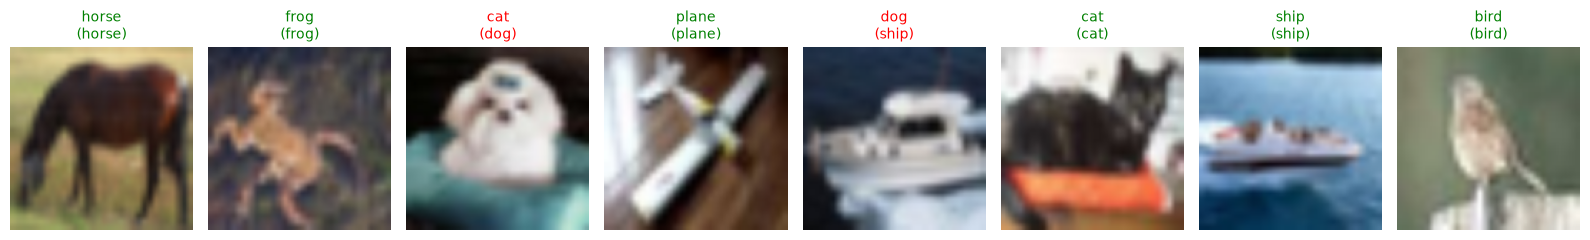

표시된 8장 중 6장 정답  (초록=정답, 빨강=오답)
틀린 것이 있다면, 사람이 봐도 헷갈릴 만한 이미지인지 살펴보세요.


In [13]:
# ========== 예측 결과 시각화 ==========
import matplotlib.pyplot as plt

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 정규화를 되돌리기 위한 값 (채널별로 적용해야 하므로 (3,1,1) 모양으로)
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def imshow_pretrained(img, ax):
    """ImageNet 정규화를 되돌려 이미지를 그린다."""
    img = img.cpu() * STD + MEAN      # 정규화 되돌리기
    img = img.clamp(0, 1)             # 0~1 범위를 벗어난 값 잘라내기
    # (채널, 높이, 너비) -> (높이, 너비, 채널)
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.axis('off')


# 테스트 데이터 한 배치 가져오기
images, labels = next(iter(tl_testloader))

# 특징 추출 모델로 예측
fe_model.eval()
with torch.no_grad():
    preds = fe_model(images.to(device)).argmax(1).cpu()

# 앞 8장만 시각화 (제목: 예측 / 괄호 안은 정답)
n_show = 8
fig, axes = plt.subplots(1, n_show, figsize=(16, 2.5))
for i, ax in enumerate(axes):
    imshow_pretrained(images[i], ax)
    is_correct = preds[i] == labels[i]
    ax.set_title(f'{classes[preds[i]]}\n({classes[labels[i]]})',
                 color='green' if is_correct else 'red', fontsize=10)
plt.tight_layout()
plt.show()

n_correct = (preds[:n_show] == labels[:n_show]).sum().item()
print(f'표시된 {n_show}장 중 {n_correct}장 정답  (초록=정답, 빨강=오답)')
print('틀린 것이 있다면, 사람이 봐도 헷갈릴 만한 이미지인지 살펴보세요.')

---

## 4-7. 전이학습에서 반드시 지켜야 할 3가지

방금 실행한 코드에 이 세 가지가 모두 들어 있다. 다시 짚어보자.

**① 입력 전처리를 사전학습 모델에 맞춘다**

```python
transforms.Resize(IMG_SIZE)                        # 크기 맞추기
transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet 표준값
                     std=[0.229, 0.224, 0.225])
```

⚠️ 앞 실습의 `Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))`를 그대로 쓰면 성능이 크게 떨어진다.
**모델이 학습된 방식과 같은 방식으로 데이터를 넣어야 한다.**

**② 마지막 층은 반드시 교체한다**

```python
model.fc = nn.Linear(model.fc.in_features, 10)   # 1000종 -> 10종
```

교체하지 않으면 출력이 1,000개로 나와서 `CrossEntropyLoss`에서 오류가 난다.

**③ 옵티마이저는 모델 수정 후에 만든다**

```python
model.fc = nn.Linear(512, 10)                     # 먼저 층을 교체하고
optimizer = optim.SGD(model.parameters(), ...)    # 그다음 옵티마이저 생성
```

순서가 바뀌면 옵티마이저가 **옛날 층**을 붙잡고 있어서 새 층이 학습되지 않는다.
(3장의 "모델을 키운 뒤 옵티마이저를 재실행해야 한다"와 같은 이유다)

---

## 4-8. 직접 해볼 실험

위 코드의 설정값을 바꿔가며 실험해 보자. **셀을 다시 실행하기만 하면 된다.**

| # | 실험 | 바꿀 것 | 관찰할 것 |
|:--:|---|---|---|
| 1 | 에포크 늘리기 | `EPOCHS = 3` | 미세조정이 특징 추출을 앞서는가 |
| 2 | 이미지 크기 | `IMG_SIZE = 224` | 정확도가 오르는가, 시간은 얼마나 늘어나는가 |
| 3 | 데이터 양 | `N_TRAIN = 1000` | 데이터가 적어도 전이학습이 통하는가 |
| 4 | **학습률의 함정** | 미세조정에 `lr=0.01` | 성능이 오히려 나빠지는가 (파괴적 망각) |
| 5 | 사전학습 없이 | `weights=None` | 사전학습이 없으면 얼마나 떨어지는가 ⭐ |
| 6 | 다른 모델 | `models.efficientnet_b0` | 더 좋은 모델은 더 좋은 결과를 내는가 |

> **⭐ 실험 5번을 꼭 해보세요**
>
> `build_resnet18` 함수에서 `weights='IMAGENET1K_V1'`을 `weights=None`으로 바꾸면
> **구조는 같지만 가중치가 무작위**인 모델이 된다.
>
> 같은 구조, 같은 학습 시간인데 결과가 크게 다를 것이다.
> **차이를 만든 것은 구조가 아니라 "이미 배워둔 지식"이라는 사실**을 직접 확인할 수 있다.

> **💡 실험 6번 힌트 — 모델마다 마지막 층 이름이 다르다**
>
> ```python
> # ResNet 계열
> model.fc = nn.Linear(model.fc.in_features, 10)
>
> # EfficientNet / VGG 계열은 classifier
> model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
> ```
>
> `print(model)`을 찍어서 **마지막 층의 이름을 직접 확인**하는 습관을 들이자.

> **⚠️ 전이학습이 만능은 아니다**
>
> | 상황 | 문제 |
> |---|---|
> | 원본과 완전히 다른 도메인 | 의료영상, 위성사진 등은 효과가 제한적일 수 있다 |
> | 사전학습 모델의 편향 | 원본 데이터의 편향까지 함께 가져온다 |
> | 라이선스 | 모델마다 상업적 이용 조건이 다르다. **반드시 확인할 것** |


---

# 5. 마무리

## 오늘 배운 것

```
   [1-2 챕터]  MLP        이미지를 한 줄로 펴서 처리 -> 위치 정보 소실
        ↓
   [3-1 챕터]  CNN        필터로 훑어서 위치 정보 유지 + 파라미터 절약
        ↓
              전이학습     남이 학습해둔 특징 추출 능력을 빌려온다
```

## 핵심 정리 5가지

| # | 내용 |
|---|---|
| 1 | **CNN은 이미지를 펴지 않는다.** 필터로 훑어서 인접 픽셀의 관계를 살린다 |
| 2 | **같은 필터를 전체에 재사용한다.** 그래서 파라미터가 적고 위치 변화에 강하다 |
| 3 | **CNN = 특징 추출부(Conv) + 분류부(MLP).** 뒷부분은 1-2에서 배운 그 MLP다 |
| 4 | **학습 4단계는 그대로다.** 순전파 -> 손실 -> 역전파 -> 업데이트 |
| 5 | **실무의 기본값은 전이학습이다.** 맨바닥 학습은 데이터와 시간이 감당 안 된다 |

## 자주 만나는 에러

| 증상 | 원인 | 해결 |
|---|---|---|
| `mat1 and mat2 shapes cannot be multiplied` | Flatten 크기 ≠ `Linear` 입력 크기 | 출력 크기를 단계별로 계산 / `print(x.shape)` |
| `Expected all tensors to be on the same device` | 모델은 GPU, 데이터는 CPU | 데이터에도 `.to(device)` |
| `CUDA out of memory` | 배치나 모델이 너무 큼 | `batch_size`를 절반으로 |
| 모델을 바꿨는데 성능이 그대로 | 옵티마이저를 재생성하지 않음 | 옵티마이저 셀 재실행 |
| 학습이 너무 느림 | `batch_size=4`가 너무 작음 | 64~128로 상향 |
| loss가 `nan` | 학습률이 너무 큼 | `lr`을 1/10로 |


## 더 나아가기

**여러 개의 GPU에서 학습하기**

모든 GPU를 활용해서 더욱 속도를 올리고 싶다면,
[선택 사항: 데이터 병렬 처리 (Data Parallelism)](https://tutorials.pytorch.kr/beginner/blitz/data_parallel_tutorial.html)를 참고하세요.

**주요 CNN 아키텍처의 발전**

오늘 만든 모델은 1998년 **LeNet** 구조와 거의 같다. 그 이후의 흐름을 알아두면 좋다.

| 모델 | 연도 | 핵심 아이디어 |
|---|---|---|
| **LeNet** | 1998 | CNN의 원형 (오늘 만든 것) |
| **AlexNet** | 2012 | ReLU + GPU 학습 -> 딥러닝 시대 개막 |
| **VGG** | 2014 | 3x3 필터를 깊게 쌓기 |
| **ResNet** | 2015 | **잔차 연결(skip connection)** 으로 100층 이상 가능 |
| **EfficientNet** | 2019 | 깊이·너비·해상도를 균형 있게 확장 |
| **ViT** | 2020 | CNN 대신 **Transformer**를 이미지에 적용 |

<br>

> 💡 **ResNet의 잔차 연결**은 2-1 과제에서 구현한 Transformer의 **Residual Connection**과 같은 아이디어다.
> `x + f(x)` 형태로 원본이 그대로 흘러가는 고속도로를 만드는 것.
> 분야는 달라도 **깊게 쌓기 위한 해법은 같았다.**


## 다음으로 해볼 만한 것

> 원문: https://tutorials.pytorch.kr/beginner/blitz/cifar10_tutorial.html

- 비디오 게임을 할 수 있는 신경망 학습시키기 (강화학습)
- ImageNet으로 최첨단(state-of-the-art) ResNet 신경망 학습시키기
- 적대적 생성 신경망(GAN)으로 얼굴 생성기 학습시키기
- 순환 LSTM 네트워크를 사용해 단어 단위 언어 모델 학습시키기
- [다른 예제들 참고하기](https://github.com/pytorch/examples)
- [더 많은 튜토리얼 보기](https://tutorials.pytorch.kr/)

---

### 📚 참고 자료

- [PyTorch 공식 CIFAR-10 튜토리얼](https://tutorials.pytorch.kr/beginner/blitz/cifar10_tutorial.html)
- [PyTorch 전이학습 튜토리얼](https://tutorials.pytorch.kr/beginner/transfer_learning_tutorial.html)
- [torchvision 사전학습 모델 목록](https://pytorch.org/vision/stable/models.html)
- [CNN Explainer — 브라우저에서 CNN 동작 시각화](https://poloclub.github.io/cnn-explainer/) ⭐ 강력 추천
